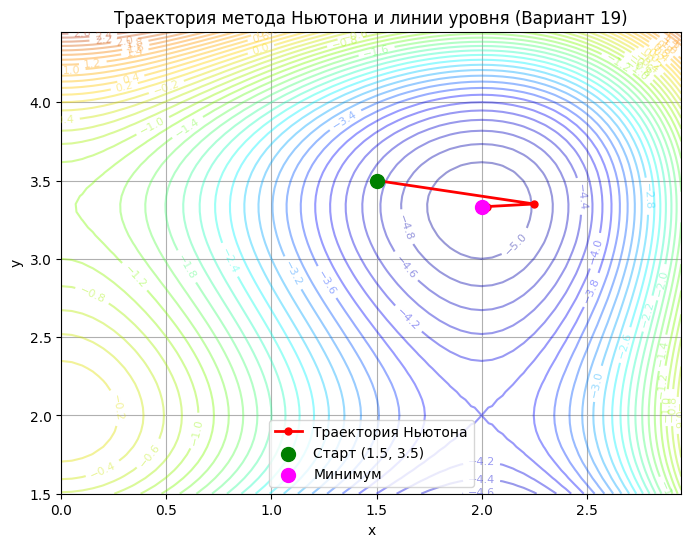

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


class NewtonOptimizer:
    def __init__(self, start_point, epsilon=1e-4):
        self.x = np.array(start_point, dtype=float)
        self.eps = epsilon
        self.history = {}

    def objective(self, x, y):
        return x**3 - 3 * x**2 + y**3 - 8 * y**2 + 20 * y - 16

    def gradient(self, p):
        x, y = p
        df_dx = 3 * x**2 - 6 * x
        df_dy = 3 * y**2 - 16 * y + 20
        return np.array([df_dx, df_dy])

    def hessian(self, p):
        x, y = p
        d2f_dx2 = 6 * x - 6
        d2f_dy2 = 6 * y - 16
        return np.array([[d2f_dx2, 0.0], [0.0, d2f_dy2]])

    def solve(self):
        idx = 0
        self.history[idx] = {
            "solution": self.x.copy(),
            "objective": self.objective(*self.x),
        }

        while True:
            grad = self.gradient(self.x)
            if np.linalg.norm(grad) < self.eps:
                break

            hess = self.hessian(self.x)
            # Нахождение шага: H * step = grad
            step = np.linalg.solve(hess, grad)
            self.x -= step

            idx += 1
            self.history[idx] = {
                "solution": self.x.copy(),
                "objective": self.objective(*self.x),
            }

            if idx > 100:  # Предотвращение зацикливания
                break

        return self.x, self.history


def plot_history(
    title: str,
    objective,
    bounds: np.ndarray,
    step_x: float,
    step_y: float,
    history: dict,
):
    xaxis_vals = np.arange(bounds[0, 0], bounds[0, 1], step_x)
    yaxis_vals = np.arange(bounds[1, 0], bounds[1, 1], step_y)
    xx, yy = np.meshgrid(xaxis_vals, yaxis_vals)
    target_grid_vals = objective(xx, yy)

    colorlist = ["darkblue", "blue", "aqua", "lawngreen", "gold", "darkorange", "brown"]
    newcmp = LinearSegmentedColormap.from_list("testCmap", colors=colorlist, N=256)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    xmin, xmax, ymin, ymax = np.amin(xx), np.amax(xx), np.amin(yy), np.amax(yy)

    contours = ax.contour(xx, yy, target_grid_vals, levels=50, cmap=newcmp, alpha=0.4)
    plt.clabel(contours, inline=1, fontsize=8)

    solutions_x = [v["solution"][0] for k, v in history.items()]
    solutions_y = [v["solution"][1] for k, v in history.items()]

    plt.plot(
        solutions_x,
        solutions_y,
        ".-",
        color="r",
        markersize=10,
        linewidth=2,
        label="Траектория Ньютона",
    )
    plt.scatter(
        solutions_x[0],
        solutions_y[0],
        color="green",
        s=100,
        zorder=5,
        label="Старт (1.5, 3.5)",
    )
    plt.scatter(
        solutions_x[-1],
        solutions_y[-1],
        color="magenta",
        s=100,
        zorder=5,
        label="Минимум",
    )

    plt.title(title)
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])
    plt.legend()
    plt.grid(True)
    plt.show()


# Инициализация и расчет
optimizer = NewtonOptimizer(start_point=[1.5, 3.5])
min_point, run_history = optimizer.solve()

# Параметры отрисовки
steps = (0.05, 0.05)
bounds = np.asarray([[0.0, 3.0], [1.5, 4.5]])

plot_history(
    "Траектория метода Ньютона и линии уровня (Вариант 19)",
    optimizer.objective,
    bounds,
    *steps,
    run_history
)